# Pauli potential scaling (vp)

Non-selfconsistent scaling study: scale the density with lambda, compute the total KE potential `vs`, subtract the von Weizsaecker potential `vvw`, and check the negative part integral of `vp`.


In [48]:
from dftpy.ions import Ions
from dftpy.field import DirectField
from dftpy.grid import DirectGrid
from dftpy.functional import LocalPseudo, Functional, TotalFunctional
from dftpy.formats import io
from dftpy.math_utils import ecut2nr
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.mpi import sprint

import matplotlib.pyplot as plt
import numpy as np


In [49]:
from dftpy.constants import environ
environ['LOGLEVEL'] = 4


## Pseudopotentials and system helpers


In [50]:
path_pp = "/Users/michele/Documents/hackathon/KEDF-scaling/OEPP_lib/OEPP/RECPOT/"

def get_pp_list(atom_type):
    import os
    matches = [f for f in os.listdir(path_pp) if f.startswith(atom_type + "_")]
    if not matches:
        raise FileNotFoundError(f"No pseudopotential found for {atom_type} in {path_pp}")
    file_pp = matches[0]
    return {atom_type: path_pp + file_pp}


def get_ions(atom_type, phase, a=None):
    if a is None:
        raise Exception("provide lattice constant")
    from ase.build import bulk
    atoms = bulk(atom_type, phase, a=a, cubic=True)
    ions = Ions.from_ase(atoms)
    return ions


## Optimize the density


In [51]:
def optimize_rho(KEDF, atom_type, phase, a, rhoi=None, **kwargs):
    ions = get_ions(atom_type, phase, a)
    nr = ecut2nr(ecut=35, lattice=ions.cell)
    grid = DirectGrid(lattice=ions.cell, nr=nr)
    PSEUDO = LocalPseudo(grid=grid, ions=ions, PP_list=get_pp_list(atom_type))
    if rhoi is None:
        rho_ini = DirectField(grid=grid)
        rho_ini[:] = ions.get_ncharges() / ions.cell.volume
    else:
        if rhoi.grid != grid:
            raise Exception("Input rho not on the same grid")
        rho_ini = rhoi
    KE = Functional(type='KEDF', name=KEDF, **kwargs)
    XC = Functional(type='XC', name='LDA')
    HARTREE = Functional(type='HARTREE')
    evaluator = TotalFunctional(KE=KE, XC=XC, HARTREE=HARTREE, PSEUDO=PSEUDO)
    opt = Optimization(EnergyEvaluator=evaluator, optimization_options={'econv': 1e-6}, optimization_method='CG')
    rho = opt.optimize_rho(guess_rho=rho_ini)
    return rho


## Pauli potential negativity on a scaled density


In [52]:
def pauli_negative_integral_on_scaled_rho(KEDF, rho_in, scale, **kwargs):
    ke = Functional(type="KEDF", name=KEDF, **kwargs)
    vw = Functional(type="KEDF", name="vW")

    grid = DirectGrid(lattice=rho_in.grid.cell / scale, nr=rho_in.grid.nr)
    rho_scaled = rho_in.copy()
    rho_scaled.grid = grid
    rho_scaled *= scale**3

    vs = ke(rho_scaled).potential
    vvw = vw(rho_scaled).potential
    vp = vs - vvw

    vp_abs = vp.copy()
    vp_abs[:] = np.abs(vp)
    vp_neg = vp.copy()
    vp_neg[:] = np.minimum(vp, 0.0)

    neg_integral = vp_neg.integral()
    neg_fraction = 2.0 * neg_integral / vp_abs.integral()
    return neg_integral, neg_fraction


## Generate the scaling curve


In [53]:
def get_pauli_positivity_curve(KEDF, rho, lambdarange=None, **kwargs):
    if lambdarange is None:
        lambdarange = np.linspace(0.1, 2.0, 30)
    neg_integrals = []
    neg_fractions = []
    for s in lambdarange:
        neg_int, neg_frac = pauli_negative_integral_on_scaled_rho(
            KEDF, rho, s, **kwargs
        )
        neg_integrals.append(neg_int)
        neg_fractions.append(neg_frac)
    return np.array(lambdarange), np.array(neg_integrals), np.array(neg_fractions)


## Example run


In [54]:
atom_type = 'Sn'
phase = 'diamond'
KEDF = 'WT' #'TFvW'
a = 4.05
KEDF_options = {"rho0": 20000000000}

rho = optimize_rho(KEDF, atom_type, phase, a, **KEDF_options)
lam, vp_neg_int, vp_neg_frac = get_pauli_positivity_curve(
    KEDF, rho, **KEDF_options
)

print(lam)
print(vp_neg_int)
print(vp_neg_frac)


[0.1        0.16551724 0.23103448 0.29655172 0.36206897 0.42758621
 0.49310345 0.55862069 0.62413793 0.68965517 0.75517241 0.82068966
 0.8862069  0.95172414 1.01724138 1.08275862 1.14827586 1.2137931
 1.27931034 1.34482759 1.41034483 1.47586207 1.54137931 1.60689655
 1.67241379 1.73793103 1.80344828 1.86896552 1.93448276 2.        ]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


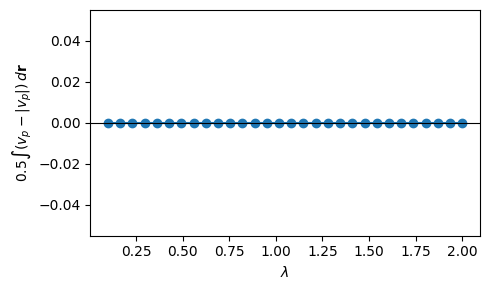

In [55]:
plt.figure(figsize=(5, 3))
plt.plot(lam, vp_neg_int, marker='o')
plt.axhline(0.0, color='k', linewidth=0.8)
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$0.5 \int (v_p - |v_p|) \, d\mathbf{r}$")
plt.tight_layout()
